In [2]:
from catboost import CatBoostRegressor
import pandas as pd
from urbanomy.methods.land_value_modeling import LandPriceEstimator

model = CatBoostRegressor()
model.load_model('../data/catboost_model.cbm')  # модель на лог-цене

In [3]:
blocks = pd.read_pickle('../data/scenario_prepared_blocks.pickle')
blocks.head()

,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,footprint_area,...,site_area,fsi,gsi,mxi,l,morphotype,area_accessibility,is_project,geometry,id
0,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.91818,LandUse.AGRICULTURE,0.918180,6260.339339,...,202399.732193,0.062008,0.030931,0.000000,2.004749,low-rise non-residential,127.337432,True,"POLYGON ((388511.373 6644951.946, 388558.037 6...",0
1,0.000000,0.938081,0.0,0.0,0.000000,0.0,0.00000,LandUse.BUSINESS,0.938081,18143.803825,...,201529.493481,0.202340,0.090031,0.000000,2.247463,low-rise non-residential,125.993903,True,"POLYGON ((388558.037 6645102.374, 388511.373 6...",1
2,0.000000,0.000000,0.0,0.0,0.891381,0.0,0.00000,LandUse.TRANSPORT,0.891381,15011.639457,...,164663.859830,0.151737,0.091165,0.000000,1.664418,low-rise non-residential,123.419051,True,"POLYGON ((387957.434 6643444.937, 388007.492 6...",2
3,0.934862,0.000000,0.0,0.0,0.000000,0.0,0.00000,LandUse.RESIDENTIAL,0.934862,22467.050757,...,161571.832511,0.449142,0.139053,0.404539,3.230005,low-rise model,122.524407,True,"POLYGON ((388007.492 6643608.409, 387957.434 6...",3
4,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.00000,None,NaN,0.316008,...,16.489152,0.079224,0.019165,0.000000,4.133894,mid-rise non-residential,122.658674,True,"POLYGON ((388001.306 6643195.969, 388000.75 66...",4


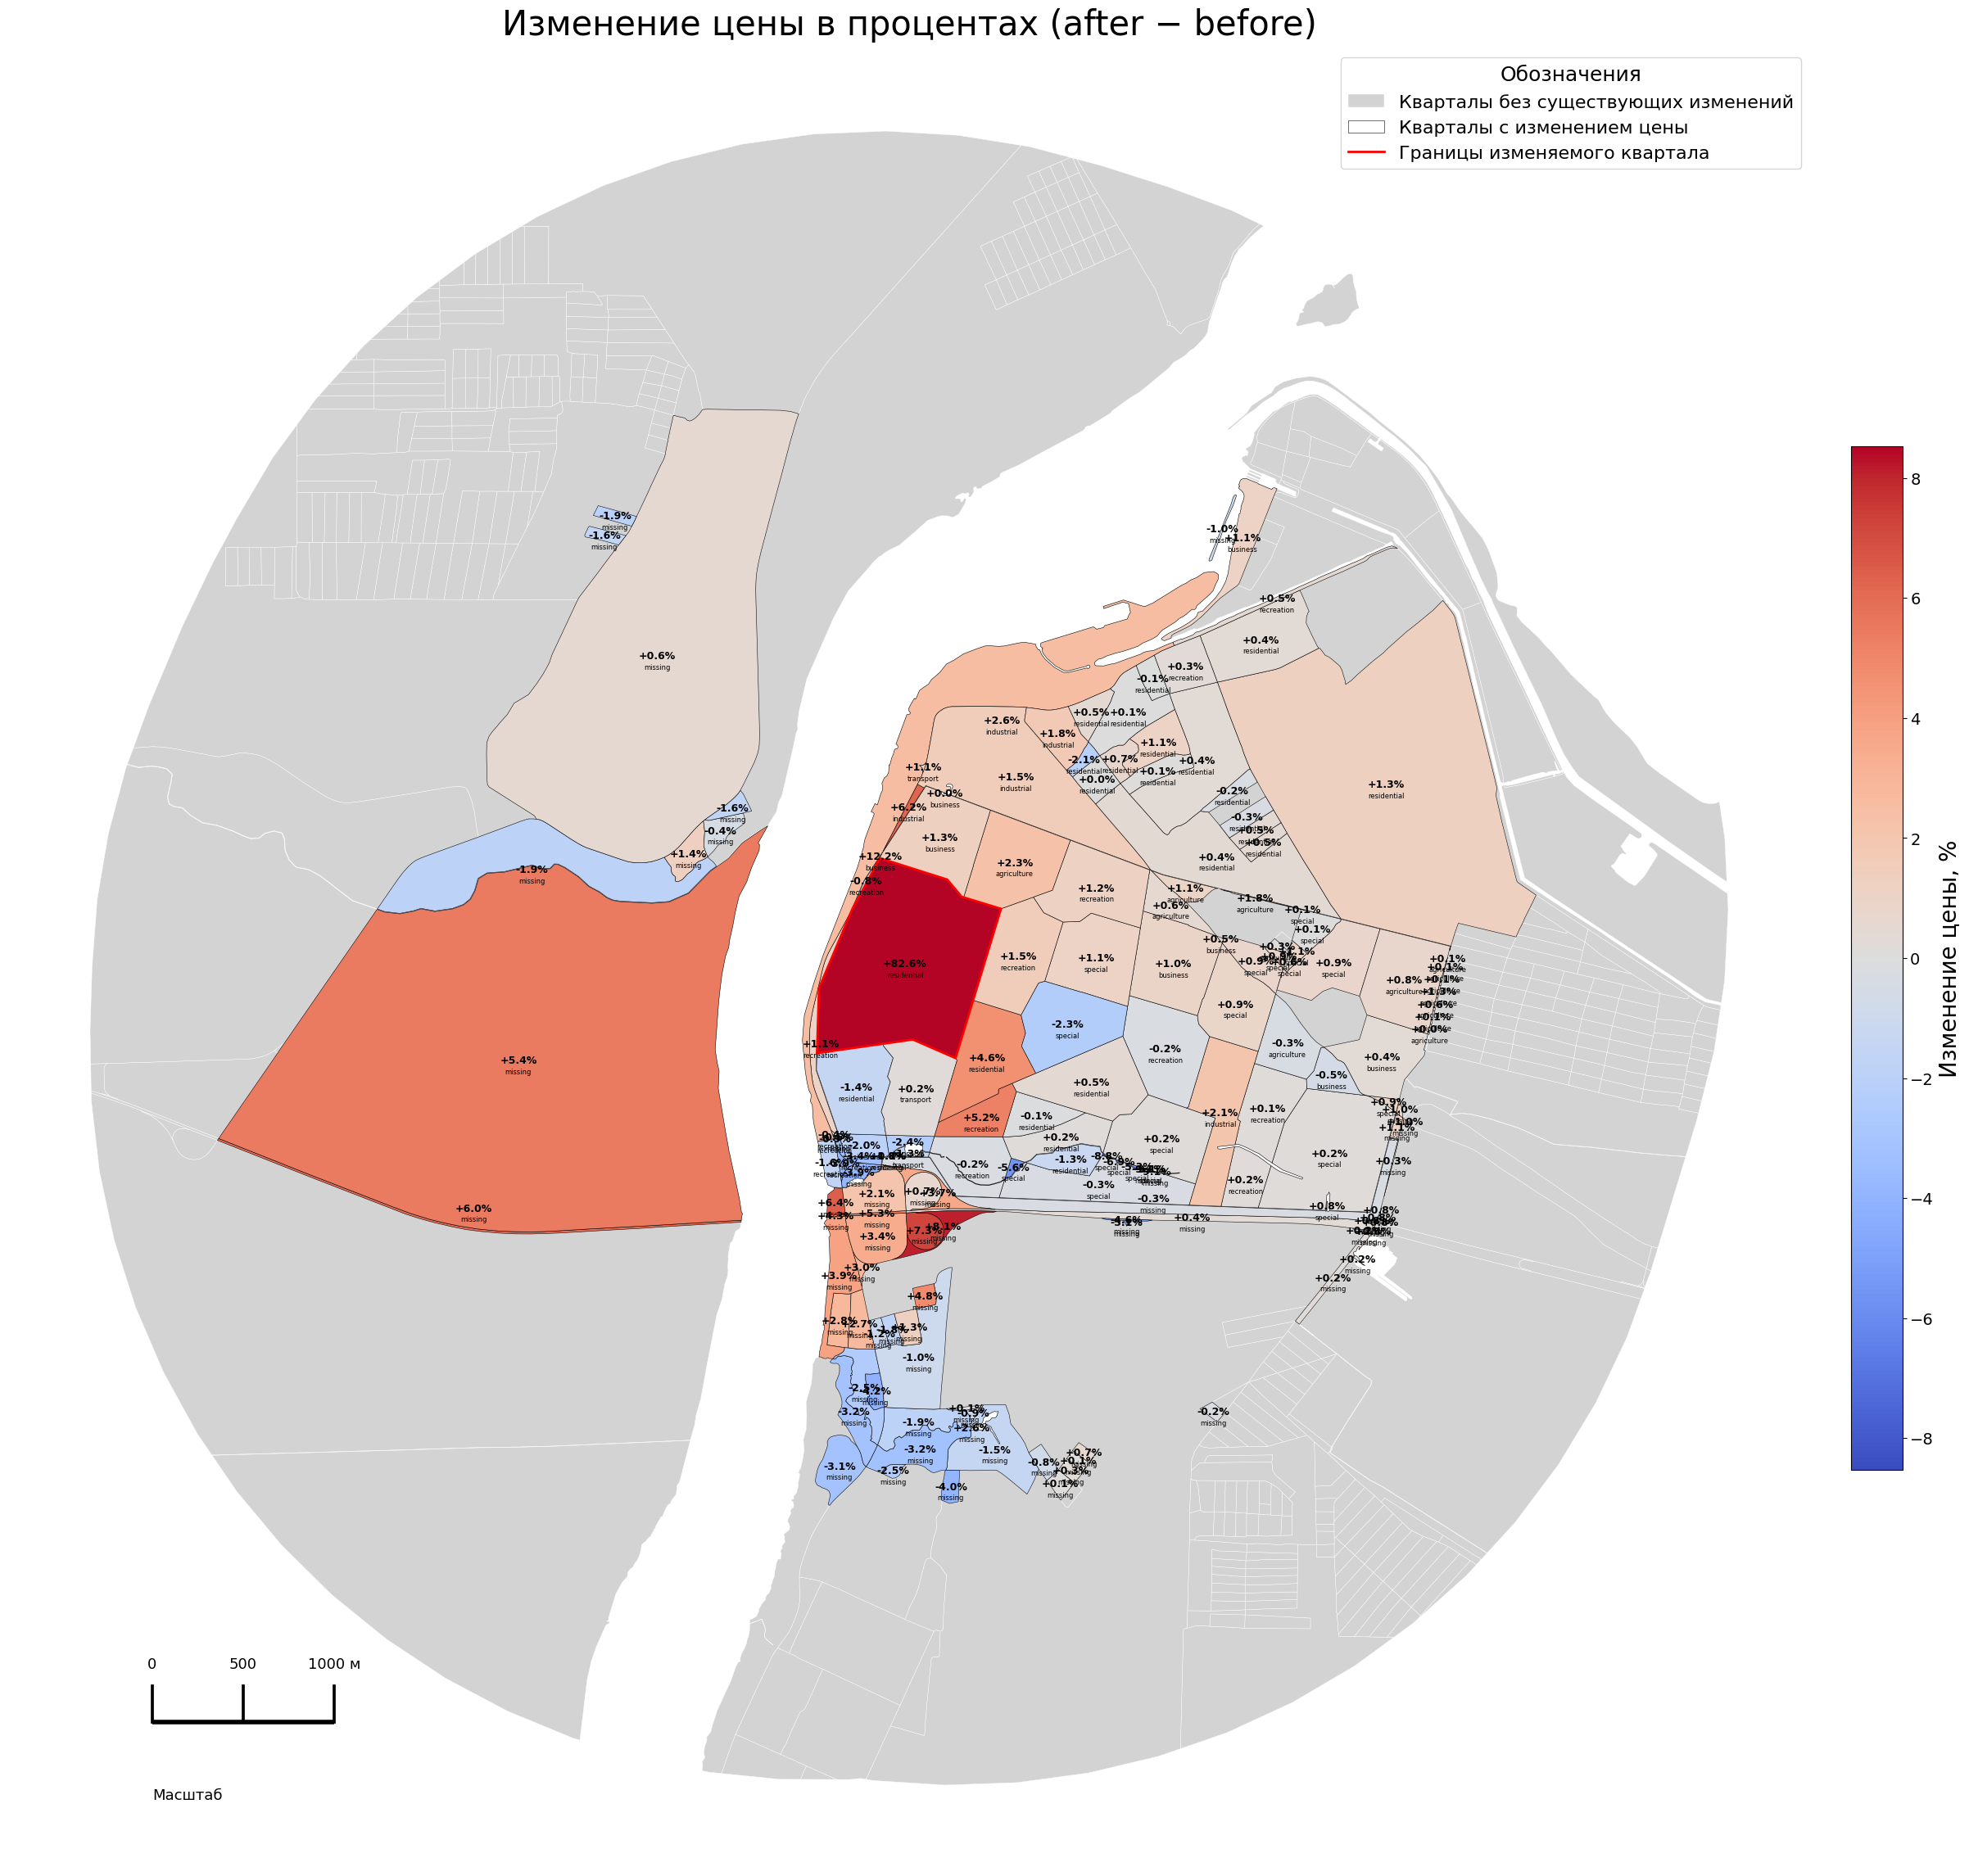


Статистика по кварталам в контексте (|Δ₽| > 1e-09):

Изменяемый квартал:
index | land_use | до (₽) → после (₽) | Δ₽ | Δ%
62 | residential | 223 337 143 ₽ → 407 776 656 ₽ | +184 439 513 ₽ | +82.6%

Кварталы в границах проекта:
index | land_use | до (₽) → после (₽) | Δ₽ | Δ%
12 | special | 162 321 450 ₽ → 161 807 582 ₽ | -513 868 ₽ | -0.3%
48 | missing | 58 415 ₽ → 53 092 ₽ | -5 323 ₽ | -9.1%
49 | special | 57 246 ₽ → 52 029 ₽ | -5 217 ₽ | -9.1%
63 | special | 8 287 150 ₽ → 8 364 865 ₽ | +77 716 ₽ | +0.9%
38 | business | 154 660 164 ₽ → 155 270 412 ₽ | +610 248 ₽ | +0.4%
69 | special | 46 663 ₽ → 47 054 ₽ | +391 ₽ | +0.8%
13 | recreation | 51 613 679 ₽ → 51 731 224 ₽ | +117 545 ₽ | +0.2%
40 | special | 274 697 126 ₽ → 275 234 655 ₽ | +537 529 ₽ | +0.2%
14 | recreation | 82 367 707 ₽ → 82 486 216 ₽ | +118 509 ₽ | +0.1%
39 | business | 43 444 744 ₽ → 43 212 758 ₽ | -231 986 ₽ | -0.5%
16 | agriculture | 92 336 583 ₽ → 92 027 811 ₽ | -308 772 ₽ | -0.3%
19 | special | 55 988 961 ₽ → 56 467 0

In [4]:
from urbanomy.methods.land_value_modeling import (
    ScenarioTEPModifier,
    plot_scenario_impact,
)

blocks_before = blocks
changes = {
    'land_use': 'LandUse.RESIDENTIAL',
    'share': 0.95,
    'footprint_area': 49039.24,
    'build_floor_area': 230279.19,
    'living_area': 155896.85,
    'population': 5168
}
target_idx = 62

modifier = ScenarioTEPModifier(blocks_before)
blocks_after = modifier.apply(target_idx, changes)

scenario_result = plot_scenario_impact(
    blocks_before=blocks_before,
    blocks_after=blocks_after,
    model=model,
    target_idx=target_idx,
    figsize=(25, 35),
)

